# RMAB ML Policy Training and Evaluation

This notebook trains a **Q-learning policy** for RMAB ICU allocation using:

- `P_icu.npy`
- `P_nonicu.npy`

Then it evaluates the learned policy against baselines and saves model artifacts.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(suppress=True, precision=4)


In [2]:
# Inputs: same as your script
P_ICU_PATH = Path('P_icu.npy')
P_NONICU_PATH = Path('P_nonicu.npy')

assert P_ICU_PATH.exists(), f'Missing {P_ICU_PATH.resolve()}'
assert P_NONICU_PATH.exists(), f'Missing {P_NONICU_PATH.resolve()}'

P_icu = np.load(P_ICU_PATH)
P_nonicu = np.load(P_NONICU_PATH)

assert P_icu.shape == P_nonicu.shape, 'P_icu and P_nonicu must have same shape'
N_STATES = P_icu.shape[0]
DEATH_STATE = N_STATES - 1

print('P_icu shape   :', P_icu.shape)
print('P_nonicu shape:', P_nonicu.shape)
print('Death state   :', DEATH_STATE)


P_icu shape   : (82, 82)
P_nonicu shape: (82, 82)
Death state   : 81


In [3]:
# Config (model/training/eval parameters)
cfg = {
    'seed': 42,

    # Q-learning
    'train_episodes': 80000,
    'train_horizon': 40,
    'gamma': 0.98,
    'alpha': 0.05,
    'epsilon_start': 0.20,
    'epsilon_end': 0.005,
    'icu_action_cost': 0.05,

    # RMAB evaluation
    'eval_episodes': 100,
    'eval_horizon': 90,
    'n_patients': 300,
    'k_new_per_day': 20,
    'icu_length': 7,

    # Reward
    'death_reward': -1.0,
}

rng = np.random.default_rng(cfg['seed'])
cfg


{'seed': 42,
 'train_episodes': 80000,
 'train_horizon': 40,
 'gamma': 0.98,
 'alpha': 0.05,
 'epsilon_start': 0.2,
 'epsilon_end': 0.005,
 'icu_action_cost': 0.05,
 'eval_episodes': 100,
 'eval_horizon': 90,
 'n_patients': 300,
 'k_new_per_day': 20,
 'icu_length': 7,
 'death_reward': -1.0}

In [4]:
def decode_state_base3(s: int):
    map_bin = s // 27
    rem = s % 27
    spo2_bin = rem // 9
    rem = rem % 9
    gcs_bin = rem // 3
    lactate_bin = rem % 3
    return map_bin, spo2_bin, gcs_bin, lactate_bin


def build_heuristic_reward(n_states: int, death_state: int, death_reward: float):
    weights = {'map': 1.0, 'spo2': 1.2, 'gcs': 1.3, 'lactate': 1.0}
    wsum = sum(weights.values())

    severity = np.zeros(n_states, dtype=float)
    reward = np.zeros(n_states, dtype=float)

    for s in range(n_states):
        if s == death_state:
            severity[s] = 1.0
            reward[s] = death_reward
            continue

        map_bin, spo2_bin, gcs_bin, lactate_bin = decode_state_base3(s)

        b_map = 2 - map_bin
        b_spo2 = 2 - spo2_bin
        b_gcs = 2 - gcs_bin
        b_lac = 2 - lactate_bin

        sev = (
            weights['map'] * b_map +
            weights['spo2'] * b_spo2 +
            weights['gcs'] * b_gcs +
            weights['lactate'] * b_lac
        ) / (2.0 * wsum)

        severity[s] = sev
        reward[s] = 1.0 - sev

    return severity, reward


def default_initial_distribution(n_states: int, death_state: int):
    p = np.zeros(n_states, dtype=float)
    anchors = [53, 44, 52, 50, 26]
    anchors = [s for s in anchors if 0 <= s < death_state]

    if anchors:
        base = np.array([0.45, 0.20, 0.15, 0.10, 0.10], dtype=float)[:len(anchors)]
        base = base / base.sum()
        p[anchors] = base
        p[:death_state] += 1e-6
    else:
        p[:death_state] = 1.0

    p[death_state] = 0.0
    p = p / p.sum()
    return p


def train_q_learning(P_nonicu, P_icu, reward, death_state, gamma, alpha, episodes, horizon, epsilon_start, epsilon_end, icu_action_cost, rng):
    n_states = P_nonicu.shape[0]
    Q = np.zeros((n_states, 2), dtype=float)
    returns = []

    for ep in range(episodes):
        frac = ep / max(1, episodes - 1)
        epsilon = epsilon_start + (epsilon_end - epsilon_start) * frac

        s = int(rng.integers(0, death_state))
        ep_return = 0.0

        for _ in range(horizon):
            if s == death_state:
                a = 0
                s_next = death_state
                r = reward[s]
            else:
                if rng.random() < epsilon:
                    a = int(rng.integers(0, 2))
                else:
                    a = int(np.argmax(Q[s]))

                probs = P_icu[s] if a == 1 else P_nonicu[s]
                s_next = int(rng.choice(n_states, p=probs))
                r = reward[s] - (icu_action_cost if a == 1 else 0.0)

            td_target = r + gamma * np.max(Q[s_next])
            Q[s, a] += alpha * (td_target - Q[s, a])

            ep_return += r
            s = s_next

        returns.append(ep_return)

    Q[death_state, 1] = -1e9
    return Q, returns


def choose_new_admissions(states, in_icu, k_new, policy_name, learned_index, one_step_index, severity, death_state, rng):
    eligible = np.where((~in_icu) & (states != death_state))[0]
    if len(eligible) == 0 or k_new <= 0:
        return np.array([], dtype=int)

    k = min(k_new, len(eligible))

    if policy_name == 'learned_q':
        score = learned_index[states[eligible]]
        chosen = eligible[np.argsort(score)[-k:]]
    elif policy_name == 'rmab_heuristic':
        score = one_step_index[states[eligible]]
        chosen = eligible[np.argsort(score)[-k:]]
    elif policy_name == 'sickest_first':
        score = severity[states[eligible]]
        chosen = eligible[np.argsort(score)[-k:]]
    elif policy_name == 'random':
        chosen = rng.choice(eligible, size=k, replace=False)
    else:
        raise ValueError(f'Unknown policy: {policy_name}')

    return chosen


def simulate_episode(P_nonicu, P_icu, reward, severity, death_state, learned_index, one_step_index, n_patients, horizon, k_new_per_day, icu_length, policy_name, init_probs, icu_action_cost, rng):
    n_states = P_nonicu.shape[0]
    states = rng.choice(n_states, size=n_patients, p=init_probs)
    icu_days_remaining = np.zeros(n_patients, dtype=int)

    cumulative_reward = 0.0
    mortality_events = 0
    icu_days = 0
    new_admissions = 0

    for _ in range(horizon):
        in_icu_before = icu_days_remaining > 0

        admits = choose_new_admissions(
            states=states,
            in_icu=in_icu_before,
            k_new=k_new_per_day,
            policy_name=policy_name,
            learned_index=learned_index,
            one_step_index=one_step_index,
            severity=severity,
            death_state=death_state,
            rng=rng,
        )

        icu_days_remaining[admits] = icu_length
        in_icu_now = icu_days_remaining > 0
        actions = in_icu_now.astype(int)

        cumulative_reward += float(reward[states].sum() - icu_action_cost * actions.sum())
        icu_days += int(actions.sum())
        new_admissions += int(len(admits))

        next_states = states.copy()
        for i in range(n_patients):
            if states[i] == death_state:
                next_states[i] = death_state
                continue
            probs = P_icu[states[i]] if actions[i] == 1 else P_nonicu[states[i]]
            next_states[i] = int(rng.choice(n_states, p=probs))

        newly_dead = (states != death_state) & (next_states == death_state)
        mortality_events += int(newly_dead.sum())

        states = next_states
        icu_days_remaining = np.maximum(icu_days_remaining - 1, 0)
        icu_days_remaining[states == death_state] = 0

    return {
        'cumulative_reward': cumulative_reward,
        'mortality_events': float(mortality_events),
        'icu_utilization': float(icu_days) / (horizon * n_patients),
        'new_icu_admissions_per_day': float(new_admissions) / horizon,
        'final_mean_severity': float(np.mean(severity[states])),
    }


def evaluate_policies(P_nonicu, P_icu, reward, severity, death_state, learned_index, one_step_index, cfg, rng):
    init_probs = default_initial_distribution(P_nonicu.shape[0], death_state)
    policies = ['learned_q', 'rmab_heuristic', 'sickest_first', 'random']

    rows = []
    for policy_name in policies:
        metrics = []
        for _ in range(cfg['eval_episodes']):
            m = simulate_episode(
                P_nonicu=P_nonicu,
                P_icu=P_icu,
                reward=reward,
                severity=severity,
                death_state=death_state,
                learned_index=learned_index,
                one_step_index=one_step_index,
                n_patients=cfg['n_patients'],
                horizon=cfg['eval_horizon'],
                k_new_per_day=cfg['k_new_per_day'],
                icu_length=cfg['icu_length'],
                policy_name=policy_name,
                init_probs=init_probs,
                icu_action_cost=cfg['icu_action_cost'],
                rng=rng,
            )
            metrics.append(m)

        out = {'policy': policy_name}
        for k in metrics[0]:
            vals = np.array([x[k] for x in metrics], dtype=float)
            out[f'{k}_mean'] = float(vals.mean())
            out[f'{k}_std'] = float(vals.std())
        rows.append(out)

    return pd.DataFrame(rows).sort_values('cumulative_reward_mean', ascending=False)


In [5]:
# Train ML policy (Q-learning)
severity, reward = build_heuristic_reward(N_STATES, DEATH_STATE, cfg['death_reward'])

Q, train_returns = train_q_learning(
    P_nonicu=P_nonicu,
    P_icu=P_icu,
    reward=reward,
    death_state=DEATH_STATE,
    gamma=cfg['gamma'],
    alpha=cfg['alpha'],
    episodes=cfg['train_episodes'],
    horizon=cfg['train_horizon'],
    epsilon_start=cfg['epsilon_start'],
    epsilon_end=cfg['epsilon_end'],
    icu_action_cost=cfg['icu_action_cost'],
    rng=rng,
)

# Learned index from Q-values
learned_index = Q[:, 1] - Q[:, 0]
learned_index[DEATH_STATE] = -np.inf

# Heuristic one-step baseline index
q_icu_1 = P_icu @ reward
q_non_1 = P_nonicu @ reward
one_step_index = q_icu_1 - q_non_1
one_step_index[DEATH_STATE] = -np.inf

print('Q shape:', Q.shape)
print('Mean train return (last 500 episodes):', float(np.mean(train_returns[-500:])))
print('Learned index stats (live states):',
      float(np.min(learned_index[:-1])),
      float(np.median(learned_index[:-1])),
      float(np.max(learned_index[:-1])))


Q shape: (82, 2)
Mean train return (last 500 episodes): 24.630077777777785
Learned index stats (live states): -6.6070962206728225 -0.40788202425795106 35.23205793266783


In [6]:
# Model parameter inspection (output)
q_table_df = pd.DataFrame({
    'state': np.arange(N_STATES),
    'Q_nonicu': Q[:, 0],
    'Q_icu': Q[:, 1],
    'learned_index': learned_index,
    'one_step_index': one_step_index,
})

q_table_df.head(12)


,state,Q_nonicu,Q_icu,learned_index,one_step_index
0,0,31.214033,33.671963,2.457930,0.00000
1,1,33.592188,31.608751,-1.983438,0.00000
2,2,34.691997,31.807499,-2.884498,0.00000
3,3,32.149593,30.937648,-1.211945,0.00000
4,4,33.746578,32.030089,-1.716489,0.00000
5,5,34.579168,32.088960,-2.490208,0.00000
6,6,32.240087,33.957083,1.716996,0.00000
7,7,34.383374,36.879971,2.496597,0.29607
8,8,33.423665,31.557249,-1.866416,0.00000
9,9,29.658926,31.703947,2.045021,0.00000


In [7]:
# Evaluate learned model vs baselines
result = evaluate_policies(
    P_nonicu=P_nonicu,
    P_icu=P_icu,
    reward=reward,
    severity=severity,
    death_state=DEATH_STATE,
    learned_index=learned_index,
    one_step_index=one_step_index,
    cfg=cfg,
    rng=np.random.default_rng(cfg['seed']),
)

result


,policy,cumulative_reward_mean,cumulative_reward_std,mortality_events_mean,mortality_events_std,icu_utilization_mean,icu_utilization_std,new_icu_admissions_per_day_mean,new_icu_admissions_per_day_std,final_mean_severity_mean,final_mean_severity_std
0,learned_q,12568.716611,1219.988952,86.98,12.771045,0.444540,0.001210,20.000000,0.000000,0.484210,0.030004
1,rmab_heuristic,11359.659611,1153.924905,99.56,10.685804,0.443805,0.001047,20.000000,0.000000,0.518293,0.028793
2,sickest_first,6970.035222,995.374191,151.22,9.402744,0.436301,0.001315,19.996667,0.015674,0.628554,0.026085
3,random,-1022.832500,916.737982,199.96,6.089204,0.412125,0.008173,18.588667,0.355344,0.756052,0.016082


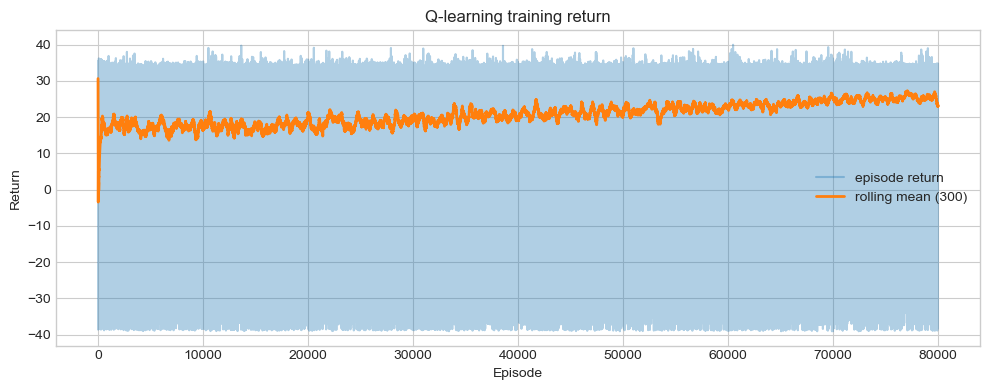

In [8]:
# Training curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_returns, alpha=0.35, label='episode return')
roll = pd.Series(train_returns).rolling(300, min_periods=1).mean()
ax.plot(roll, linewidth=2, label='rolling mean (300)')
ax.set_title('Q-learning training return')
ax.set_xlabel('Episode')
ax.set_ylabel('Return')
ax.legend()
plt.tight_layout()
plt.show()


In [9]:
# Save model parameters + evaluation outputs
out_dir = Path('artifacts') / 'rmab_ml_notebook'
out_dir.mkdir(parents=True, exist_ok=True)

np.save(out_dir / 'Q_table.npy', Q)
np.save(out_dir / 'learned_index.npy', learned_index)
np.save(out_dir / 'one_step_index.npy', one_step_index)

pd.DataFrame({'episode': np.arange(len(train_returns)), 'return': train_returns}).to_csv(out_dir / 'train_returns.csv', index=False)
q_table_df.to_csv(out_dir / 'q_table_inspect.csv', index=False)
result.to_csv(out_dir / 'policy_comparison.csv', index=False)

summary = {
    'config': cfg,
    'n_states': int(N_STATES),
    'death_state': int(DEATH_STATE),
    'best_policy': str(result.iloc[0]['policy']),
    'outputs': {
        'Q_table': 'Q_table.npy',
        'learned_index': 'learned_index.npy',
        'one_step_index': 'one_step_index.npy',
        'train_returns': 'train_returns.csv',
        'q_table_inspect': 'q_table_inspect.csv',
        'policy_comparison': 'policy_comparison.csv',
    }
}
(out_dir / 'summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')

print('Saved artifacts to:', out_dir.resolve())
print(json.dumps(summary, indent=2))


Saved artifacts to: /Users/jason/Desktop/GT/AI for Social Impact/RMAB-MIMIC/artifacts/rmab_ml_notebook
{
  "config": {
    "seed": 42,
    "train_episodes": 80000,
    "train_horizon": 40,
    "gamma": 0.98,
    "alpha": 0.05,
    "epsilon_start": 0.2,
    "epsilon_end": 0.005,
    "icu_action_cost": 0.05,
    "eval_episodes": 100,
    "eval_horizon": 90,
    "n_patients": 300,
    "k_new_per_day": 20,
    "icu_length": 7,
    "death_reward": -1.0
  },
  "n_states": 82,
  "death_state": 81,
  "best_policy": "learned_q",
  "outputs": {
    "Q_table": "Q_table.npy",
    "learned_index": "learned_index.npy",
    "one_step_index": "one_step_index.npy",
    "train_returns": "train_returns.csv",
    "q_table_inspect": "q_table_inspect.csv",
    "policy_comparison": "policy_comparison.csv"
  }
}
